In [1]:
!pip install meteostat scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 34.9 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires p

In [2]:
!pip install pandas==2.2.2 meteostat

INFO: pip is looking at multiple versions of meteostat to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 72.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.1
    Uninstalling pandas-3.0.1:
      Successfully uninstalled pandas-3.0.1
  Attempting uninstall: meteostat
    Found existing installation: meteostat 2.1.4
    Uninstalling meteostat-2.1.4:
      Successfully uninstalled meteostat-2.1.4


In [3]:
import pandas as pd
print(pd.__version__)

2.2.2


In [7]:
import pandas as pd

url = "https://data.cityofnewyork.us/resource/ez4e-fazm.csv?$limit=50000&$select=Occurred_On,Reason,Boro,How_Long_Delayed,Route_Number&$order=Occurred_On%20DESC"

buses = pd.read_csv(url)
print(buses.shape)
print(buses.columns.tolist())
print(buses["How_Long_Delayed"].value_counts(dropna=False).head(15))

(50000, 5)
['Occurred_On', 'Reason', 'Boro', 'How_Long_Delayed', 'Route_Number']
How_Long_Delayed
16-30 Min    17531
61-90 Min    10996
31-45 Min     8932
0-15 Min      5758
46-60 Min     4327
NaN           2456
Name: count, dtype: int64


In [8]:
import re
import numpy as np

def parse_delay(val):
    if pd.isna(val) or str(val).strip() in ("", "nan"):
        return np.nan
    v = str(val).lower().strip()

    # "0-15 min late" or "15 to 30 min late" → midpoint
    m = re.search(r"(\d+)\s*[-–to]+\s*(\d+)", v)
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2

    # "30+ min late" → 45
    m = re.search(r"(\d+)\s*\+", v)
    if m:
        return float(m.group(1)) + 15

    # plain number
    m = re.search(r"(\d+\.?\d*)", v)
    if m:
        return float(m.group(1))

    return np.nan

buses["delay_minutes"] = buses["How_Long_Delayed"].apply(parse_delay)
print(buses["delay_minutes"].describe())
print("Nulls:", buses["delay_minutes"].isna().sum())

count    47544.000000
mean        38.813373
std         23.252776
min          7.500000
25%         23.000000
50%         38.000000
75%         53.000000
max         75.500000
Name: delay_minutes, dtype: float64
Nulls: 2456


In [9]:
# Parse timestamp
buses["Occurred_On"] = pd.to_datetime(buses["Occurred_On"], errors="coerce")
buses = buses.dropna(subset=["Occurred_On", "delay_minutes"])
buses = buses[(buses["delay_minutes"] > 0) & (buses["delay_minutes"] <= 120)]

# Time features
buses["date"]         = buses["Occurred_On"].dt.date
buses["hour"]         = buses["Occurred_On"].dt.hour
buses["day_of_week"]  = buses["Occurred_On"].dt.dayofweek   # 0 = Monday
buses["month"]        = buses["Occurred_On"].dt.month
buses["is_weekend"]   = (buses["day_of_week"] >= 5).astype(int)
buses["is_rush_hour"] = buses["hour"].apply(
    lambda h: 1 if (7 <= h <= 9 or 17 <= h <= 19) else 0
)

# Group reasons into categories
reason_map = {
    "Heavy Traffic":          "Traffic",
    "Other":                  "Other",
    "Mechanical Problem":     "Mechanical",
    "Problem Run":            "Operational",
    "Flat Tire":              "Mechanical",
    "Weather Conditions":     "Weather",
    "Won`t Start":            "Mechanical",
    "Won't Start":            "Mechanical",
    "Accident":               "Accident",
    "Snow":                   "Weather",
    "Heavy Rain":             "Weather",
    "Frozen Bus":             "Weather",
    "Stalled":                "Mechanical",
    "Late Return From Field": "Operational",
    "Delay By School":        "Operational",
    "Student Behavior":       "Operational",
}
buses["reason_category"] = buses["Reason"].str.strip().map(reason_map).fillna("Other")
buses["Boro"] = buses["Boro"].fillna("Unknown").str.strip().str.title()

print(f"Clean rows: {len(buses)}")
print(buses["reason_category"].value_counts())

Clean rows: 47544
reason_category
Traffic        30545
Other           8618
Operational     4929
Weather         3191
Accident         261
Name: count, dtype: int64


In [10]:
from meteostat import Point, Daily
from datetime import datetime
import pandas as pd

# NYC Central Park weather station
nyc   = Point(40.7812, -73.9665)
start = datetime(buses["date"].min().year,
                 buses["date"].min().month,
                 buses["date"].min().day)
end   = datetime(buses["date"].max().year,
                 buses["date"].max().month,
                 buses["date"].max().day)

weather = Daily(nyc, start, end).fetch().reset_index()
weather = weather.rename(columns={"time": "date"})
weather["date"] = pd.to_datetime(weather["date"]).dt.date

# Fill gaps
weather["prcp"] = weather["prcp"].fillna(0)
weather["snow"] = weather["snow"].fillna(0)
weather["tavg"] = weather["tavg"].fillna(weather["tavg"].median())
weather["wspd"] = weather["wspd"].fillna(weather["wspd"].median())

# Weather flags
weather["is_raining"] = (weather["prcp"] > 2).astype(int)
weather["is_snowing"]  = (weather["snow"] > 0).astype(int)
weather["is_cold"]     = (weather["tavg"] < 2).astype(int)
weather["is_windy"]    = (weather["wspd"] > 30).astype(int)
weather["bad_weather"] = (
    (weather["is_raining"] | weather["is_snowing"] | weather["is_windy"])
).astype(int)

print(weather[["date","tavg","prcp","snow","wspd"]].head(10))
print(f"\nRainy days: {weather['is_raining'].sum()}")
print(f"Snowy days: {weather['is_snowing'].sum()}")

         date  tavg  prcp  snow  wspd
0  2025-10-21  14.8   0.0   0.0  10.0
1  2025-10-22  14.3   0.5   0.0   8.8
2  2025-10-23  12.2   0.0   0.0   8.6
3  2025-10-24  11.3   0.0   0.0   8.1
4  2025-10-25  11.3   0.0   0.0   5.7
5  2025-10-26  11.7   0.0   0.0   6.1
6  2025-10-27   9.6   0.0   0.0   7.2
7  2025-10-28   9.8   0.0   0.0  14.8
8  2025-10-29  11.1   0.2   0.0  14.7
9  2025-10-30  13.8  12.8   0.0  12.0

Rainy days: 6
Snowy days: 45


In [11]:
df = buses.merge(weather, on="date", how="inner")
print(f"Merged rows: {len(df)}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")

Merged rows: 47544
Date range: 2025-10-21 → 2026-03-27


In [12]:
TARGET = "delay_minutes"

print("=== Avg delay by reason ===")
print(df.groupby("reason_category")[TARGET].mean().sort_values(ascending=False).round(1))

print("\n=== Avg delay: Rain vs No Rain ===")
print(df.groupby("is_raining")[TARGET].mean().round(1))

print("\n=== Avg delay: Snow vs No Snow ===")
print(df.groupby("is_snowing")[TARGET].mean().round(1))

print("\n=== Avg delay: Rush hour vs Off-peak ===")
print(df.groupby("is_rush_hour")[TARGET].mean().round(1))

print("\n=== Feature correlations with delay ===")
num_cols = ["tavg","prcp","snow","wspd","is_raining","is_snowing",
            "is_cold","is_windy","bad_weather","hour","day_of_week",
            "month","is_weekend","is_rush_hour"]
corr = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)
print(corr.sort_values(key=abs, ascending=False).round(3))

=== Avg delay by reason ===
reason_category
Weather        50.1
Accident       43.5
Traffic        39.8
Other          37.0
Operational    28.4
Name: delay_minutes, dtype: float64

=== Avg delay: Rain vs No Rain ===
is_raining
0    38.8
1    38.8
Name: delay_minutes, dtype: float64

=== Avg delay: Snow vs No Snow ===
is_snowing
0    37.9
1    40.4
Name: delay_minutes, dtype: float64

=== Avg delay: Rush hour vs Off-peak ===
is_rush_hour
0    43.1
1    33.3
Name: delay_minutes, dtype: float64

=== Feature correlations with delay ===
is_rush_hour   -0.208
snow            0.090
is_snowing      0.052
bad_weather     0.051
hour            0.039
tavg           -0.031
month          -0.027
is_cold         0.021
wspd           -0.016
prcp           -0.007
day_of_week     0.001
is_weekend     -0.000
is_raining      0.000
is_windy          NaN
Name: delay_minutes, dtype: float64



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



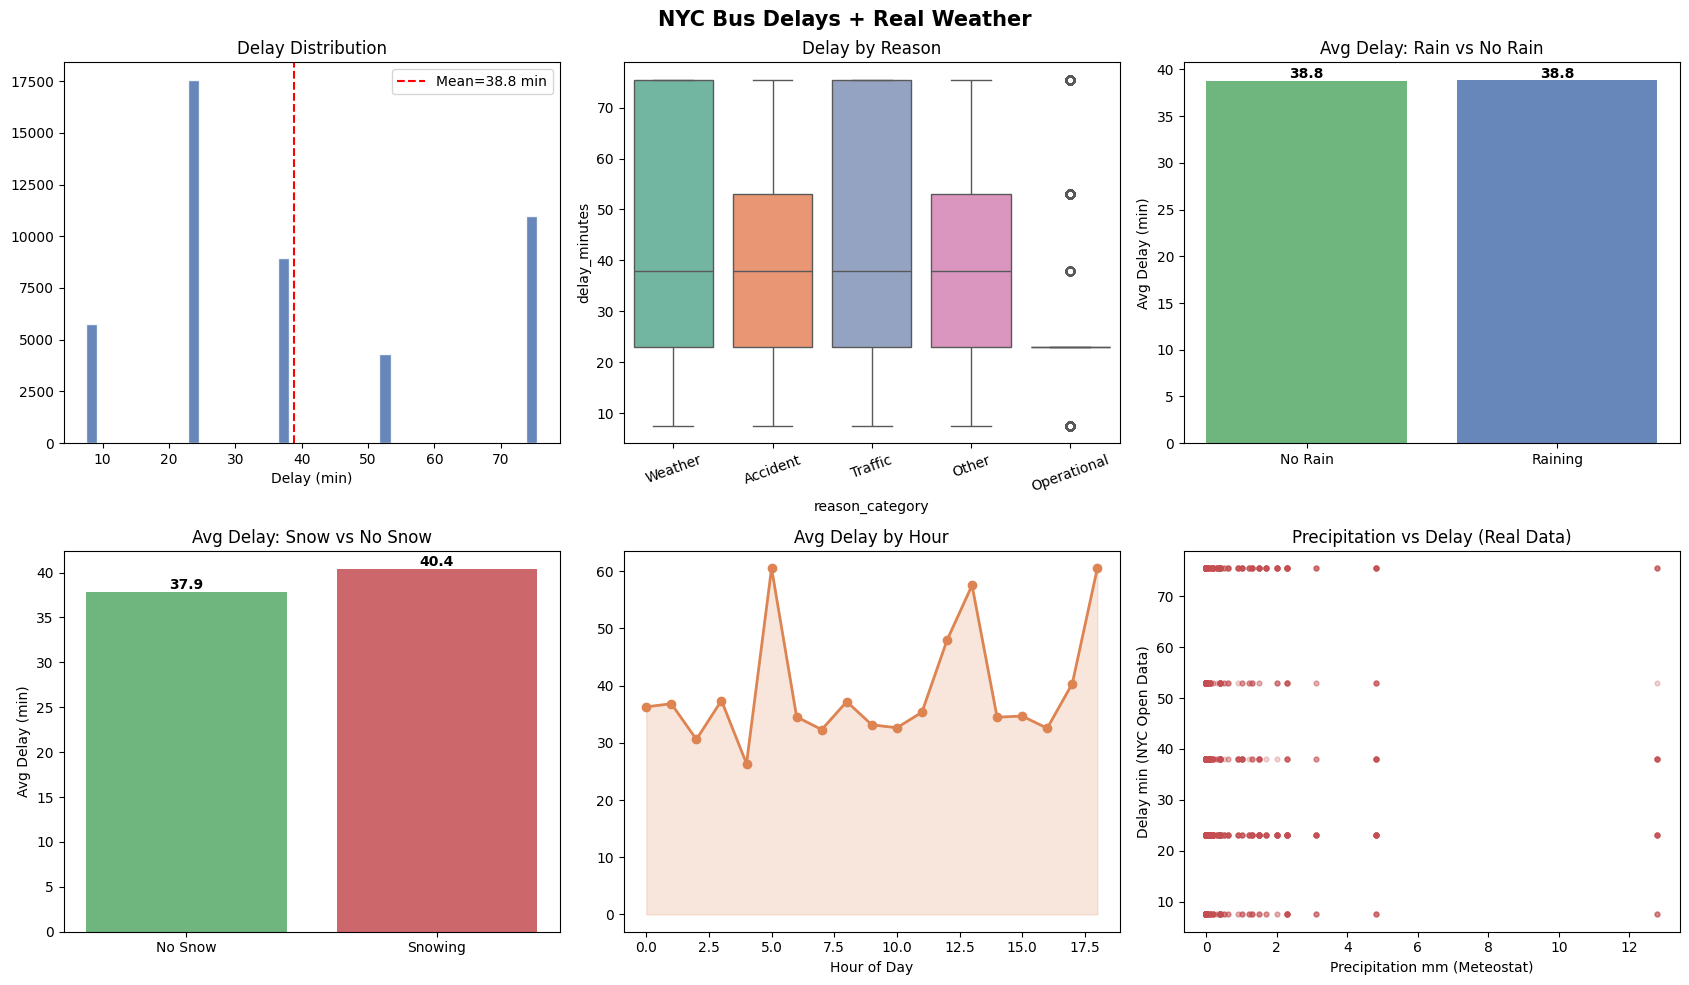

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("NYC Bus Delays + Real Weather", fontsize=15, fontweight="bold")

# Delay distribution
ax = axes[0, 0]
ax.hist(df[TARGET], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(df[TARGET].mean(), color="red", linestyle="--",
           label=f"Mean={df[TARGET].mean():.1f} min")
ax.set_title("Delay Distribution")
ax.set_xlabel("Delay (min)")
ax.legend()

# Delay by reason
ax = axes[0, 1]
order = df.groupby("reason_category")[TARGET].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="reason_category", y=TARGET, order=order,
            ax=ax, palette="Set2")
ax.set_title("Delay by Reason")
ax.tick_params(axis="x", rotation=20)

# Rain impact
ax = axes[0, 2]
vals = df.groupby("is_raining")[TARGET].mean()
ax.bar(["No Rain", "Raining"], vals.values, color=["#55A868","#4C72B0"], alpha=0.85)
ax.set_title("Avg Delay: Rain vs No Rain")
ax.set_ylabel("Avg Delay (min)")
for i, v in enumerate(vals.values):
    ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontweight="bold")

# Snow impact
ax = axes[1, 0]
vals = df.groupby("is_snowing")[TARGET].mean()
ax.bar(["No Snow", "Snowing"], vals.values, color=["#55A868","#C44E52"], alpha=0.85)
ax.set_title("Avg Delay: Snow vs No Snow")
ax.set_ylabel("Avg Delay (min)")
for i, v in enumerate(vals.values):
    ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontweight="bold")

# Hourly pattern
ax = axes[1, 1]
hourly = df.groupby("hour")[TARGET].mean()
ax.plot(hourly.index, hourly.values, marker="o", color="#DD8452", linewidth=2)
ax.fill_between(hourly.index, hourly.values, alpha=0.2, color="#DD8452")
ax.set_title("Avg Delay by Hour")
ax.set_xlabel("Hour of Day")

# Precipitation scatter
ax = axes[1, 2]
s = df.sample(min(3000, len(df)), random_state=42)
ax.scatter(s["prcp"], s[TARGET], alpha=0.25, color="#C44E52", s=12)
ax.set_title("Precipitation vs Delay (Real Data)")
ax.set_xlabel("Precipitation mm (Meteostat)")
ax.set_ylabel("Delay min (NYC Open Data)")

plt.tight_layout()
plt.savefig("eda.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features
feat_cols = [
    "hour","day_of_week","month","is_weekend","is_rush_hour",
    "tavg","prcp","snow","wspd",
    "is_raining","is_snowing","is_cold","is_windy","bad_weather",
    "reason_category","Boro"
]

df_feat = df[feat_cols + [TARGET]].copy()
for col in ["reason_category", "Boro"]:
    df_feat[col] = LabelEncoder().fit_transform(df_feat[col].astype(str))

X = df_feat.drop(columns=[TARGET])
y = df_feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Baseline (mean)":   DummyRegressor(strategy="mean"),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=300, max_depth=12,
                             min_samples_leaf=4, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                             max_depth=5, subsample=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:<25}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:+.3f}")

Baseline (mean)            MAE=19.60  RMSE=23.27  R²=-0.000
Ridge Regression           MAE=18.42  RMSE=21.83  R²=+0.120
Random Forest              MAE=12.26  RMSE=17.21  R²=+0.453
Gradient Boosting          MAE=12.85  RMSE=17.44  R²=+0.438


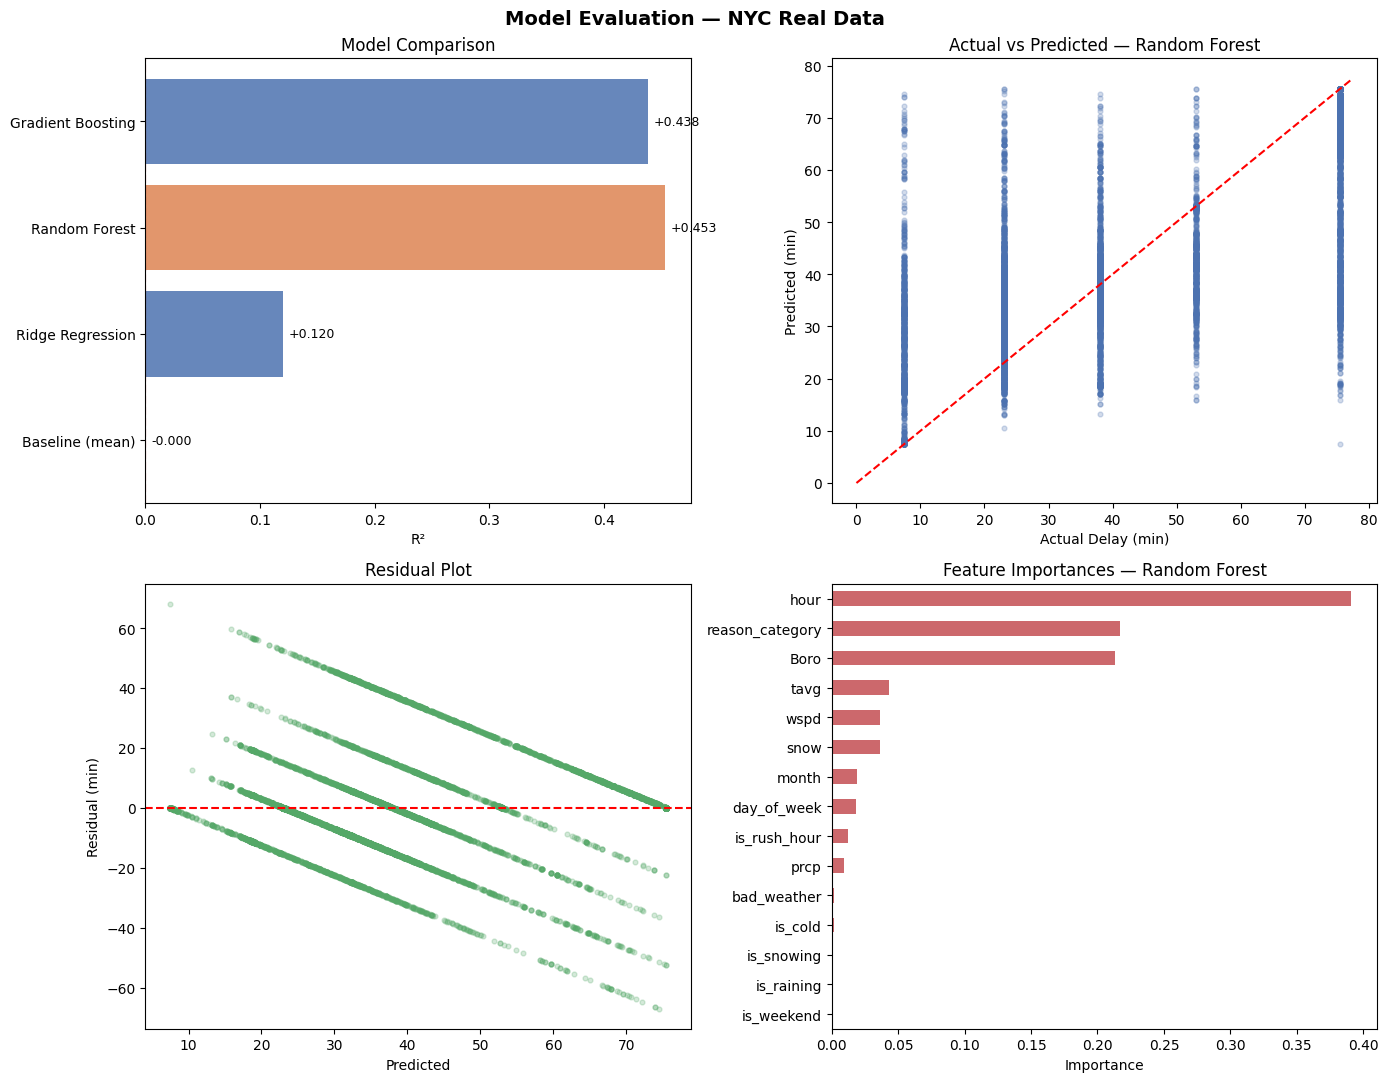

In [15]:
best_name = max({n: r for n, r in results.items() if "Baseline" not in n},
                key=lambda n: results[n]["R2"])
best = results[best_name]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Model Evaluation — NYC Real Data", fontsize=14, fontweight="bold")

# Model comparison
ax = axes[0, 0]
names_r = list(results.keys())
r2_vals = [results[n]["R2"] for n in names_r]
colors  = ["#AAAAAA" if "Baseline" in n else
           "#DD8452" if n == best_name else "#4C72B0" for n in names_r]
bars = ax.barh(names_r, r2_vals, color=colors, alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("R²")
ax.set_title("Model Comparison")
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", fontsize=9)

# Actual vs Predicted
ax = axes[0, 1]
preds = best["preds"]
ax.scatter(y_test, preds, alpha=0.25, s=12, color="#4C72B0")
lim = max(y_test.max(), preds.max()) + 2
ax.plot([0, lim], [0, lim], "r--", linewidth=1.5)
ax.set_xlabel("Actual Delay (min)")
ax.set_ylabel("Predicted (min)")
ax.set_title(f"Actual vs Predicted — {best_name}")

# Residuals
ax = axes[1, 0]
residuals = y_test.values - preds
ax.scatter(preds, residuals, alpha=0.25, s=12, color="#55A868")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted")
ax.set_ylabel("Residual (min)")
ax.set_title("Residual Plot")

# Feature importances
tree_models = {n: r for n, r in results.items()
               if n not in ("Baseline (mean)", "Ridge Regression")}
best_tree = max(tree_models, key=lambda n: tree_models[n]["R2"])
ax = axes[1, 1]
imp = pd.Series(results[best_tree]["model"].feature_importances_,
                index=X.columns).nlargest(15).sort_values()
imp.plot(kind="barh", ax=ax, color="#C44E52", alpha=0.85)
ax.set_title(f"Feature Importances — {best_tree}")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
plt.show()